Plot Figure 2a
--

In [1]:
cd ~/Pythons/

/home/users/guicha/Pythons


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import BoundaryNorm

from config import IUMFIGDIR
from IUM.make_anomalies.twb.make_twb_radius_ctrl_rm import load_twb_radius_ctrl_rm
from IUM.make_anomalies.twb.make_twb_radius_pert_rm import load_twb_radius_pert_rm

Done
Done
Done
Done
Done
Done


In [8]:
### CST ###

var = 'twb'
res = 0.5
value = 0.3
value_pert = 1.
lengths = [25, 30, 35, 50, 75, 100, 125, 150]
u = 4.
env = 'stable'
date = '10010101'
time = 15
window = 3

if var == 'twb':
    flab = 'a'
elif var == 'hi':
    flab = 'b'  # for Supp Mat

In [6]:
data_r_max = {}

for length in lengths:
    print('\n%i km'%length)

    data = load_twb_radius_pert_rm(res=res, variable=var, value=value, value_pert=value_pert, length=length, u=u, env=env, date=date, window=window)

    data_r_max_ = data[length/2][0]  # -> sample 3-h Twb averaged over wet patch  / r_max
    data_r_max[length] = data_r_max_

data_dry = load_twb_radius_ctrl_rm(res=res, variable=var, value=value, u=u, env=env, date=date, window=window)
data_wet = load_twb_radius_ctrl_rm(res=res, variable=var, value=value_pert, u=u, env=env, date=date, window=window)

data_max_dry = data_dry[100][0]
data_max_wet = data_wet[100][0]


25 km

30 km

35 km

50 km

75 km

100 km

125 km

150 km


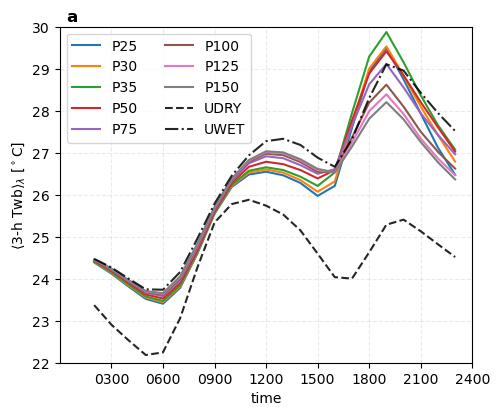

In [9]:
ts = np.arange(len(data_max_dry)) + 1
xtcks = np.arange(3, 24+3, 3)
xtlbs = [str(xt).zfill(2) + '00' for xt in xtcks]

if var == 'twb':
    var_ = 'Twb'
    ylims = (22., 30.)
elif var == 'hi':
    var_ = 'HI'
    ylims = (22., 53.)


fig, ax = plt.subplots()

plt.subplots_adjust(top=0.95, right=0.95)

for length, vals in data_r_max.items():
    length_ = length / 2

    ax.plot(ts, vals, label='P%i'%length)

ax.plot(ts, data_max_dry, color='k', ls='--', alpha=0.85, label='UDRY')
ax.plot(ts, data_max_wet, color='k', ls='-.', alpha=0.85, label='UWET')

ax.text(0.015, 1.015, flab, weight='bold', fontsize=12, transform=ax.transAxes)

ax.set_xlim(0, 24)
ax.set_xticks(xtcks)
ax.set_xticklabels(xtlbs)
ax.set_xlabel('time')
ax.set_ylim(ylims)
ax.set_ylabel("$\\langle$%i-h %s$\\rangle_{\lambda}$ [$^\circ$C]"%(window, var_))
ax.grid(True, alpha=0.25, ls='--')
ax.legend(loc='upper left', ncol=2)

fig.set_size_inches(5., 4.)